In [1]:
print("hello BATCHNORM+DROPOUT")

hello BATCHNORM+DROPOUT


In [2]:
!pip install kaggle==1.5.16

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.6/83.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.5.16-py3-none-any.whl size=110682 sha256=51cda94eca123cedab68020e922ee52bd7a0b99cb9275f5973e0cf056cdad6ff
  Stored in directory: /root/.cache/pip/wheels/6a/2e/62/475f9443c6f7f73b3beb46e121e2d30f1fb77af8bc7ba7edd6
Successfully built kaggle
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [3]:
! chmod 600 .kaggle/kaggle.json

chmod: cannot access '.kaggle/kaggle.json': No such file or directory


In [4]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

 99% 281M/285M [00:02<00:00, 150MB/s]
100% 285M/285M [00:02<00:00, 138MB/s]


In [5]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge.zip

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


In [6]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


In [7]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

In [8]:
x_train = np.array([
    list(map(int, row.split()))
    for row in train_df['pixels']
]).reshape(-1, 48, 48)

y_train = train_df['emotion'].values

In [9]:
from sklearn.model_selection import train_test_split

x_train = x_train / 255.0
x_train = x_train.reshape(-1, 1, 48, 48)

X_train, X_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

Train shape: (22967, 1, 48, 48)
Val shape: (5742, 1, 48, 48)


In [10]:
class FERDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_dataset = FERDataset(X_train, y_train)
val_dataset   = FERDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [11]:
class BNormDropoutCNN(nn.Module):
    def __init__(self, dropout_rate=0.25):
        super(BNormDropoutCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.fc(x)
        return x

model = BNormDropoutCNN().to(device)
print(model)

dummy = torch.randn(1, 1, 48, 48).to(device)
print("Output shape:", model(dummy).shape)

BNormDropoutCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode

In [12]:
!pip install wandb -q
import wandb
wandb.login()  # will prompt for API key

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ikvas22 (ikvas22-free-university-of-tbilisi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

[bndropout-cnn-adam-lr0.001-drop0.25] Epoch 1/30 | Train Loss: 1.7738 Acc: 0.2712 | Val Loss: 1.5481 Acc: 0.4014
[bndropout-cnn-adam-lr0.001-drop0.25] Epoch 2/30 | Train Loss: 1.5674 Acc: 0.3903 | Val Loss: 1.4349 Acc: 0.4417
[bndropout-cnn-adam-lr0.001-drop0.25] Epoch 3/30 | Train Loss: 1.4670 Acc: 0.4237 | Val Loss: 1.3583 Acc: 0.4742
[bndropout-cnn-adam-lr0.001-drop0.25] Epoch 4/30 | Train Loss: 1.4079 Acc: 0.4550 | Val Loss: 1.3068 Acc: 0.5019
[bndropout-cnn-adam-lr0.001-drop0.25] Epoch 5/30 | Train Loss: 1.3582 Acc: 0.4715 | Val Loss: 1.2820 Acc: 0.5225
[bndropout-cnn-adam-lr0.001-drop0.25] Epoch 6/30 | Train Loss: 1.3136 Acc: 0.4951 | Val Loss: 1.2423 Acc: 0.5178
[bndropout-cnn-adam-lr0.001-drop0.25] Epoch 7/30 | Train Loss: 1.2877 Acc: 0.5018 | Val Loss: 1.2499 Acc: 0.5104
[bndropout-cnn-adam-lr0.001-drop0.25] Epoch 8/30 | Train Loss: 1.2602 Acc: 0.5131 | Val Loss: 1.2209 Acc: 0.5343
[bndropout-cnn-adam-lr0.001-drop0.25] Epoch 9/30 | Train Loss: 1.2373 Acc: 0.5268 | Val Loss: 1.

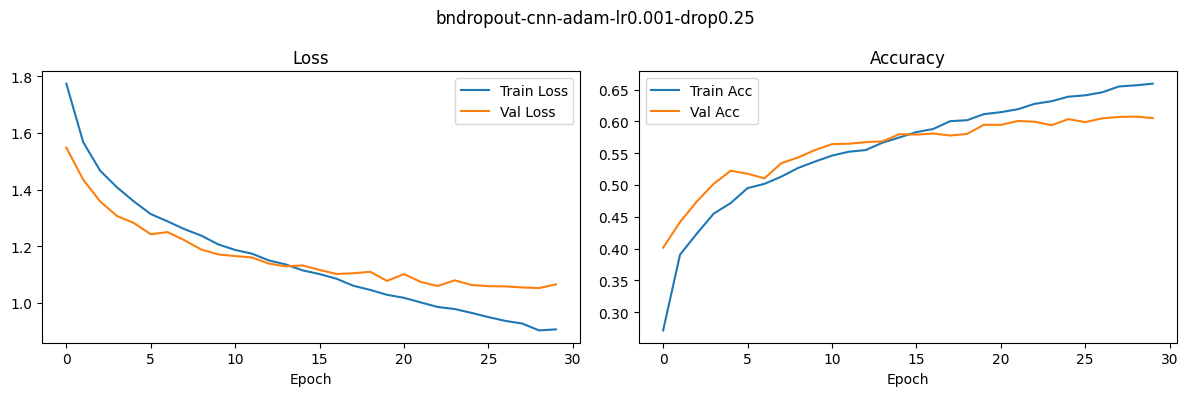

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇███████
train/loss,█▆▆▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val/accuracy,▁▂▃▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇███████████
val/loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.60763
best_val_loss,1.05236
epoch,30
final_train_accuracy,0.65942
overfit_gap,0.05406
train/accuracy,0.65942



✅ Finished: bndropout-cnn-adam-lr0.001-drop0.25



[bndropout-cnn-adam-lr0.001-drop0.5] Epoch 1/30 | Train Loss: 1.8443 Acc: 0.2428 | Val Loss: 1.8061 Acc: 0.2562
[bndropout-cnn-adam-lr0.001-drop0.5] Epoch 2/30 | Train Loss: 1.8151 Acc: 0.2501 | Val Loss: 1.8040 Acc: 0.2562
[bndropout-cnn-adam-lr0.001-drop0.5] Epoch 3/30 | Train Loss: 1.8145 Acc: 0.2501 | Val Loss: 1.8036 Acc: 0.2562
[bndropout-cnn-adam-lr0.001-drop0.5] Epoch 4/30 | Train Loss: 1.8146 Acc: 0.2501 | Val Loss: 1.8048 Acc: 0.2562
[bndropout-cnn-adam-lr0.001-drop0.5] Epoch 5/30 | Train Loss: 1.8147 Acc: 0.2501 | Val Loss: 1.8041 Acc: 0.2562
[bndropout-cnn-adam-lr0.001-drop0.5] Epoch 6/30 | Train Loss: 1.8136 Acc: 0.2501 | Val Loss: 1.8035 Acc: 0.2562
[bndropout-cnn-adam-lr0.001-drop0.5] Epoch 7/30 | Train Loss: 1.8143 Acc: 0.2501 | Val Loss: 1.8031 Acc: 0.2562
[bndropout-cnn-adam-lr0.001-drop0.5] Epoch 8/30 | Train Loss: 1.8138 Acc: 0.2501 | Val Loss: 1.8025 Acc: 0.2562
[bndropout-cnn-adam-lr0.001-drop0.5] Epoch 9/30 | Train Loss: 1.8136 Acc: 0.2501 | Val Loss: 1.8022 Acc:

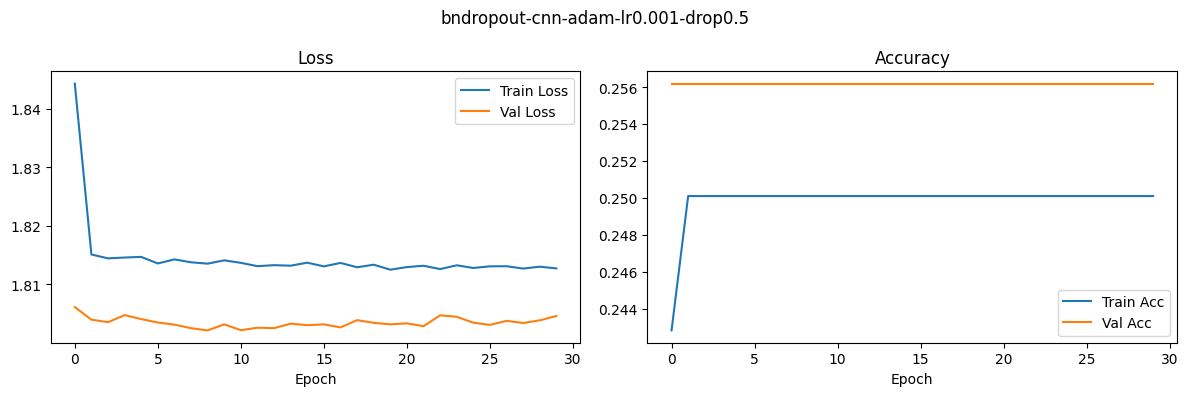

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁█████████████████████████████
train/loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▄▃▆▄▃▃▂▁▃▁▂▂▃▃▃▂▄▃▃▃▂▆▅▃▃▄▃▄▅
best_val_accuracy,0.25618
best_val_loss,1.80216
epoch,30
final_train_accuracy,0.2501
overfit_gap,-0.00608
train/accuracy,0.2501



✅ Finished: bndropout-cnn-adam-lr0.001-drop0.5



[bndropout-cnn-adam-lr0.0001-drop0.25] Epoch 1/30 | Train Loss: 1.7909 Acc: 0.2559 | Val Loss: 1.6745 Acc: 0.3424
[bndropout-cnn-adam-lr0.0001-drop0.25] Epoch 2/30 | Train Loss: 1.6511 Acc: 0.3497 | Val Loss: 1.5211 Acc: 0.4171
[bndropout-cnn-adam-lr0.0001-drop0.25] Epoch 3/30 | Train Loss: 1.5477 Acc: 0.3974 | Val Loss: 1.4440 Acc: 0.4378
[bndropout-cnn-adam-lr0.0001-drop0.25] Epoch 4/30 | Train Loss: 1.4859 Acc: 0.4264 | Val Loss: 1.3900 Acc: 0.4646
[bndropout-cnn-adam-lr0.0001-drop0.25] Epoch 5/30 | Train Loss: 1.4364 Acc: 0.4418 | Val Loss: 1.3502 Acc: 0.4796
[bndropout-cnn-adam-lr0.0001-drop0.25] Epoch 6/30 | Train Loss: 1.3955 Acc: 0.4615 | Val Loss: 1.3059 Acc: 0.4951
[bndropout-cnn-adam-lr0.0001-drop0.25] Epoch 7/30 | Train Loss: 1.3564 Acc: 0.4758 | Val Loss: 1.2842 Acc: 0.5031
[bndropout-cnn-adam-lr0.0001-drop0.25] Epoch 8/30 | Train Loss: 1.3257 Acc: 0.4898 | Val Loss: 1.2440 Acc: 0.5254
[bndropout-cnn-adam-lr0.0001-drop0.25] Epoch 9/30 | Train Loss: 1.2986 Acc: 0.5012 | Val

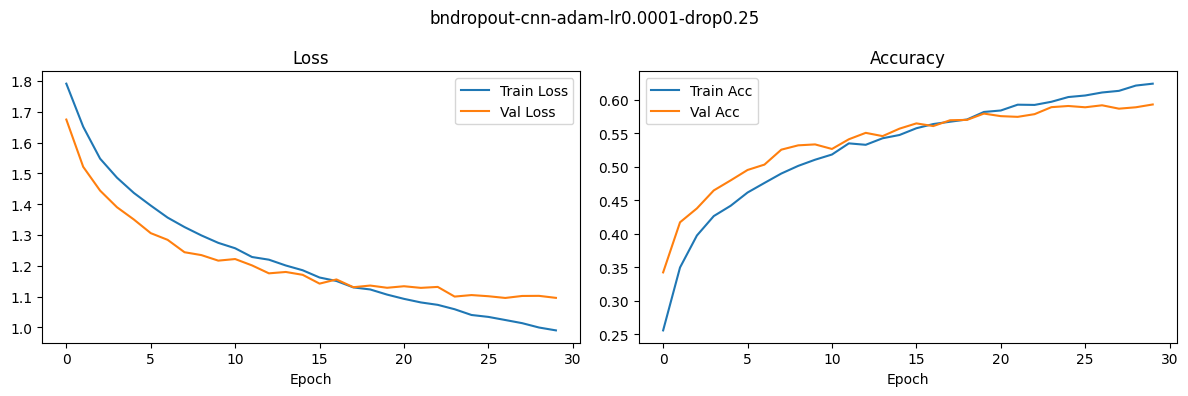

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████
train/loss,█▇▆▅▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val/accuracy,▁▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇██▇████████
val/loss,█▆▅▅▄▄▃▃▃▂▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.59282
best_val_loss,1.09567
epoch,30
final_train_accuracy,0.62385
overfit_gap,0.03103
train/accuracy,0.62385



✅ Finished: bndropout-cnn-adam-lr0.0001-drop0.25



[bndropout-cnn-sgd-lr0.01-drop0.25] Epoch 1/30 | Train Loss: 1.7782 Acc: 0.2604 | Val Loss: 1.6474 Acc: 0.3488
[bndropout-cnn-sgd-lr0.01-drop0.25] Epoch 2/30 | Train Loss: 1.6290 Acc: 0.3571 | Val Loss: 1.5202 Acc: 0.4253
[bndropout-cnn-sgd-lr0.01-drop0.25] Epoch 3/30 | Train Loss: 1.5321 Acc: 0.4032 | Val Loss: 1.4335 Acc: 0.4624
[bndropout-cnn-sgd-lr0.01-drop0.25] Epoch 4/30 | Train Loss: 1.4786 Acc: 0.4268 | Val Loss: 1.3690 Acc: 0.4629
[bndropout-cnn-sgd-lr0.01-drop0.25] Epoch 5/30 | Train Loss: 1.4264 Acc: 0.4464 | Val Loss: 1.3442 Acc: 0.4784
[bndropout-cnn-sgd-lr0.01-drop0.25] Epoch 6/30 | Train Loss: 1.3868 Acc: 0.4664 | Val Loss: 1.3773 Acc: 0.4638
[bndropout-cnn-sgd-lr0.01-drop0.25] Epoch 7/30 | Train Loss: 1.3606 Acc: 0.4739 | Val Loss: 1.2973 Acc: 0.4972
[bndropout-cnn-sgd-lr0.01-drop0.25] Epoch 8/30 | Train Loss: 1.3234 Acc: 0.4878 | Val Loss: 1.2468 Acc: 0.5171
[bndropout-cnn-sgd-lr0.01-drop0.25] Epoch 9/30 | Train Loss: 1.3013 Acc: 0.4984 | Val Loss: 1.2314 Acc: 0.5247
[

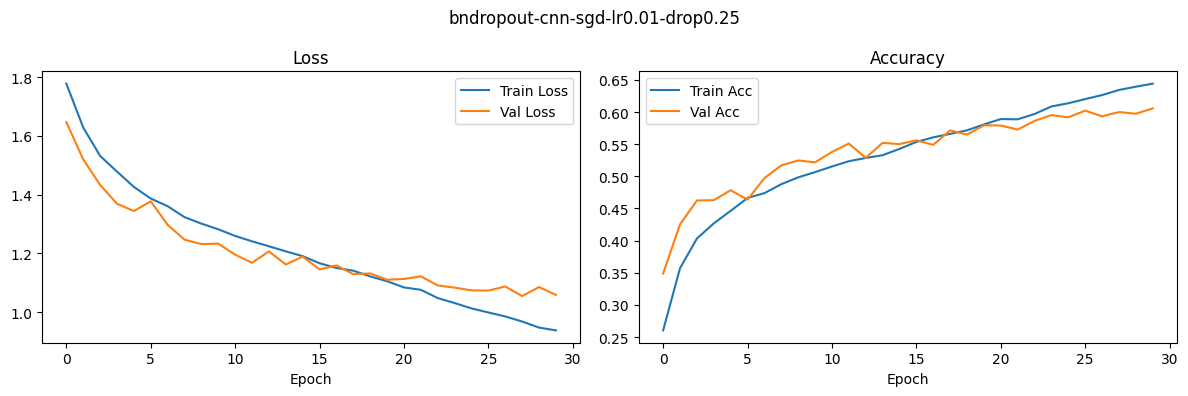

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████
train/loss,█▇▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁
val/accuracy,▁▃▄▄▅▄▅▆▆▆▆▇▆▇▆▇▆▇▇▇▇▇▇███████
val/loss,█▆▅▅▄▅▄▃▃▃▃▂▃▂▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
best_val_accuracy,0.60571
best_val_loss,1.05437
epoch,30
final_train_accuracy,0.64414
overfit_gap,0.03843
train/accuracy,0.64414



✅ Finished: bndropout-cnn-sgd-lr0.01-drop0.25



[bndropout-cnn-adam-batch128-drop0.25] Epoch 1/30 | Train Loss: 1.7985 Acc: 0.2542 | Val Loss: 1.6604 Acc: 0.3314
[bndropout-cnn-adam-batch128-drop0.25] Epoch 2/30 | Train Loss: 1.5937 Acc: 0.3718 | Val Loss: 1.4446 Acc: 0.4537
[bndropout-cnn-adam-batch128-drop0.25] Epoch 3/30 | Train Loss: 1.4908 Acc: 0.4220 | Val Loss: 1.3905 Acc: 0.4765
[bndropout-cnn-adam-batch128-drop0.25] Epoch 4/30 | Train Loss: 1.4114 Acc: 0.4482 | Val Loss: 1.3438 Acc: 0.4965
[bndropout-cnn-adam-batch128-drop0.25] Epoch 5/30 | Train Loss: 1.3692 Acc: 0.4702 | Val Loss: 1.2888 Acc: 0.5134
[bndropout-cnn-adam-batch128-drop0.25] Epoch 6/30 | Train Loss: 1.3310 Acc: 0.4852 | Val Loss: 1.2796 Acc: 0.5084
[bndropout-cnn-adam-batch128-drop0.25] Epoch 7/30 | Train Loss: 1.2986 Acc: 0.5002 | Val Loss: 1.2323 Acc: 0.5185
[bndropout-cnn-adam-batch128-drop0.25] Epoch 8/30 | Train Loss: 1.2702 Acc: 0.5119 | Val Loss: 1.2202 Acc: 0.5387
[bndropout-cnn-adam-batch128-drop0.25] Epoch 9/30 | Train Loss: 1.2425 Acc: 0.5242 | Val

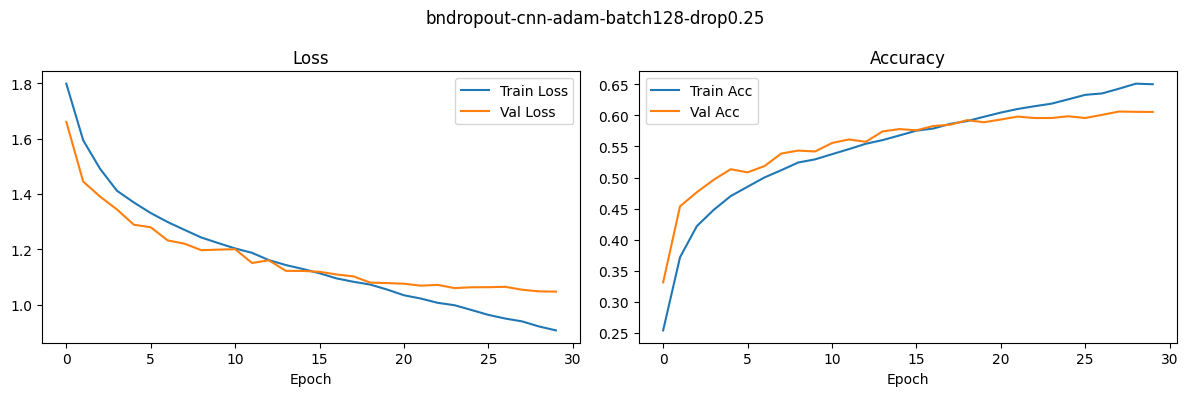

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▃▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████
train/loss,█▆▆▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁
val/accuracy,▁▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇████████████
val/loss,█▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.60623
best_val_loss,1.04705
epoch,30
final_train_accuracy,0.65011
overfit_gap,0.04457
train/accuracy,0.65011



✅ Finished: bndropout-cnn-adam-batch128-drop0.25



In [13]:
import wandb
from torch.optim import Adam, SGD, RMSprop

experiments = [
    {
        "name": "bndropout-cnn-adam-lr0.001-drop0.25",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 30,
        "dropout_rate": 0.25,
    },
    {
        "name": "bndropout-cnn-adam-lr0.001-drop0.5",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 30,
        "dropout_rate": 0.5,
    },
    {
        "name": "bndropout-cnn-adam-lr0.0001-drop0.25",
        "learning_rate": 0.0001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 30,
        "dropout_rate": 0.25,
    },
    {
        "name": "bndropout-cnn-sgd-lr0.01-drop0.25",
        "learning_rate": 0.01,
        "optimizer": "SGD",
        "batch_size": 64,
        "epochs": 30,
        "dropout_rate": 0.25,
    },
    {
        "name": "bndropout-cnn-adam-batch128-drop0.25",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 128,
        "epochs": 30,
        "dropout_rate": 0.25,
    },
]

def get_optimizer(name, model, lr):
    if name == "Adam":
        return Adam(model.parameters(), lr=lr)
    elif name == "SGD":
        return SGD(model.parameters(), lr=lr, momentum=0.9)
    elif name == "RMSprop":
        return RMSprop(model.parameters(), lr=lr)

def run_experiment(config):
    run = wandb.init(
        project="Facial_Expression_Recognition",
        name=config["name"],
        group="bndropout-cnn",
        tags=["bndropout-cnn", "batchnorm", "dropout", config["optimizer"].lower()],
        config={
            **config,
            "architecture": "BNormDropoutCNN",
            "num_conv_layers": 2,
            "conv_filters": [32, 64],
            "fc_units": 256,
            "batch_norm": True,
            "dropout": True,
            "dataset": "FER2013"
        }
    )

    model = BNormDropoutCNN(dropout_rate=config["dropout_rate"]).to(device)
    optimizer = get_optimizer(config["optimizer"], model, config["learning_rate"])
    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)

    wandb.watch(model, log="all", log_freq=10)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(config["epochs"]):
        # --- Train ---
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        # --- Validate ---
        model.eval()
        total_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                total_loss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        val_loss = total_loss / len(val_loader)
        val_acc  = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        wandb.log({
            "epoch": epoch + 1,
            "train/loss": train_loss,
            "train/accuracy": train_acc,
            "val/loss": val_loss,
            "val/accuracy": val_acc,
        })

        print(f"[{config['name']}] Epoch {epoch+1}/{config['epochs']} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # --- Plot & Log ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(config["name"])

    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(train_accs, label='Train Acc')
    ax2.plot(val_accs, label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    wandb.log({"training_curves": wandb.Image(fig)})
    plt.show()
    plt.close(fig)

    # --- Summary ---
    wandb.summary["best_val_accuracy"]    = max(val_accs)
    wandb.summary["best_val_loss"]        = min(val_losses)
    wandb.summary["final_train_accuracy"] = train_accs[-1]
    wandb.summary["overfit_gap"]          = train_accs[-1] - val_accs[-1]

    wandb.finish()
    print(f"\n✅ Finished: {config['name']}\n{'='*60}\n")

for config in experiments:
    run_experiment(config)